# 🩺 Breast Cancer Detection System Using CNN (VGG16 Transfer Learning)

**Dataset:** BUSI — Breast Ultrasound Images Dataset  
**Task:** Binary Classification — Benign vs Malignant  
**Architecture:** VGG16 Transfer Learning + Custom Head  
**Team Members:** Aiman Ijaz (F2024-0642), Tayyaba Akhtar (F2024-0798)  

---
### 📋 Notebook Sections
1. Environment Setup & Library Imports
2. Dataset Upload & Extraction
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Augmentation
5. Model Architecture (VGG16 Transfer Learning)
6. Phase 1 Training — Feature Extraction
7. Phase 2 Training — Fine-Tuning
8. Model Evaluation (Accuracy, Confusion Matrix, ROC-AUC, F1)
9. Prediction on New Images
10. Save Model & Export
11. Streamlit App Code (copy-paste ready)


---
## ⚙️ Section 1 — Environment Setup & Library Imports

In [6]:
# Install / verify key packages (Colab usually has these, but pinning versions is good practice)
!pip install -q tensorflow==2.15.0 scikit-learn matplotlib seaborn pillow

import os
import shutil
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Global constants
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_P1  = 20   # Phase 1 — frozen backbone
EPOCHS_P2  = 15   # Phase 2 — fine-tuning last conv block
NUM_CLASSES = 2
CLASS_NAMES = ['benign', 'malignant']

print('\n✅ All libraries imported successfully.')

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ All libraries imported successfully.


---
## 📂 Section 2 — Dataset Upload & Extraction

> **Instructions:**  
> Upload your `archive.zip` file when prompted (the file containing `Dataset_BUSI_with_GT/`).  
> Alternatively, if you already have it on Google Drive, mount your Drive and set `ZIP_PATH` accordingly.

In [2]:
# ── OPTION A: Upload zip directly ────────────────────────────────────────────
from google.colab import files

print('Please upload your archive.zip file:')
uploaded = files.upload()          # click "Choose Files" → select archive.zip
ZIP_PATH = list(uploaded.keys())[0]
print(f'\nUploaded: {ZIP_PATH}')

Please upload your archive.zip file:


Saving archive.zip to archive.zip

Uploaded: archive.zip


In [3]:
# ── OPTION B (alternative): Mount Google Drive instead ───────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# ZIP_PATH = '/content/drive/MyDrive/archive.zip'   # adjust path as needed

In [7]:
# ── Extract zip ──────────────────────────────────────────────────────────────
EXTRACT_DIR = '/content/busi_dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print('Extracted files:')
for root, dirs, files_list in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:   # show file counts at leaf dirs
        print(f'{indent}  → {len(files_list)} files')

Extracted files:
busi_dataset/
  archive/
    Dataset_BUSI_with_GT/
      → 0 files
      benign/
      malignant/


In [8]:
# ── Locate the BUSI root and exclude mask images ─────────────────────────────
# The zip has structure: archive/Dataset_BUSI_with_GT/{benign,malignant,normal}/
# We only keep benign & malignant (binary classification) and skip *_mask.png files.

BUSI_ROOT = None
for root, dirs, _ in os.walk(EXTRACT_DIR):
    if 'benign' in dirs and 'malignant' in dirs:
        BUSI_ROOT = root
        break

assert BUSI_ROOT is not None, 'Could not find dataset folder — check zip structure'
print(f'Dataset root: {BUSI_ROOT}')

# Build a cleaned dataset directory (images only, no masks, binary classes)
CLEAN_DIR = '/content/busi_clean'
for cls in CLASS_NAMES:
    os.makedirs(f'{CLEAN_DIR}/{cls}', exist_ok=True)

copied = {cls: 0 for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    src_dir = os.path.join(BUSI_ROOT, cls)
    for fname in os.listdir(src_dir):
        if '_mask' in fname:        # skip ground-truth masks
            continue
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            shutil.copy(os.path.join(src_dir, fname),
                        os.path.join(CLEAN_DIR, cls, fname))
            copied[cls] += 1

print('\nCleaned dataset summary:')
for cls, n in copied.items():
    print(f'  {cls}: {n} images')
print(f'  Total: {sum(copied.values())} images')

Dataset root: /content/busi_dataset/archive/Dataset_BUSI_with_GT

Cleaned dataset summary:
  benign: 437 images
  malignant: 210 images
  Total: 647 images


---
## 📊 Section 3 — Exploratory Data Analysis (EDA)

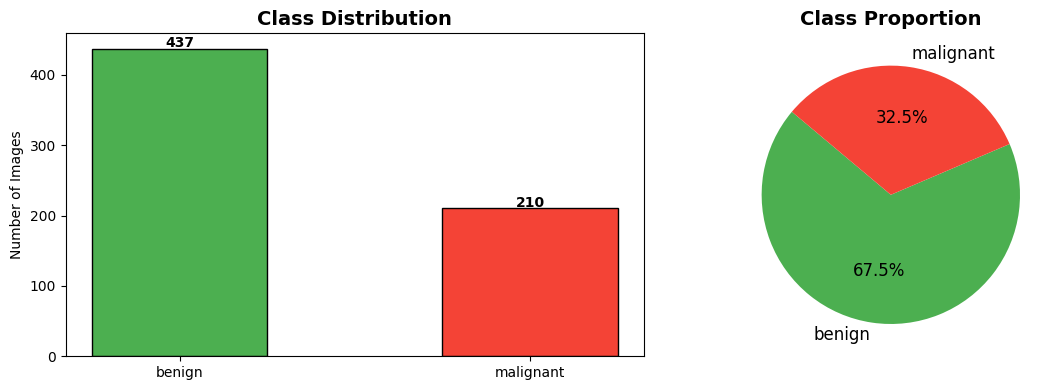

Class imbalance ratio (benign:malignant): 2.08


In [9]:
# Class distribution bar chart
counts = {cls: len(os.listdir(f'{CLEAN_DIR}/{cls}')) for cls in CLASS_NAMES}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.keys(), counts.values(),
            color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, (cls, n) in enumerate(counts.items()):
    axes[0].text(i, n + 2, str(n), ha='center', fontweight='bold')

axes[1].pie(counts.values(), labels=counts.keys(),
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class imbalance ratio (benign:malignant):',
      round(counts['benign']/counts['malignant'], 2))

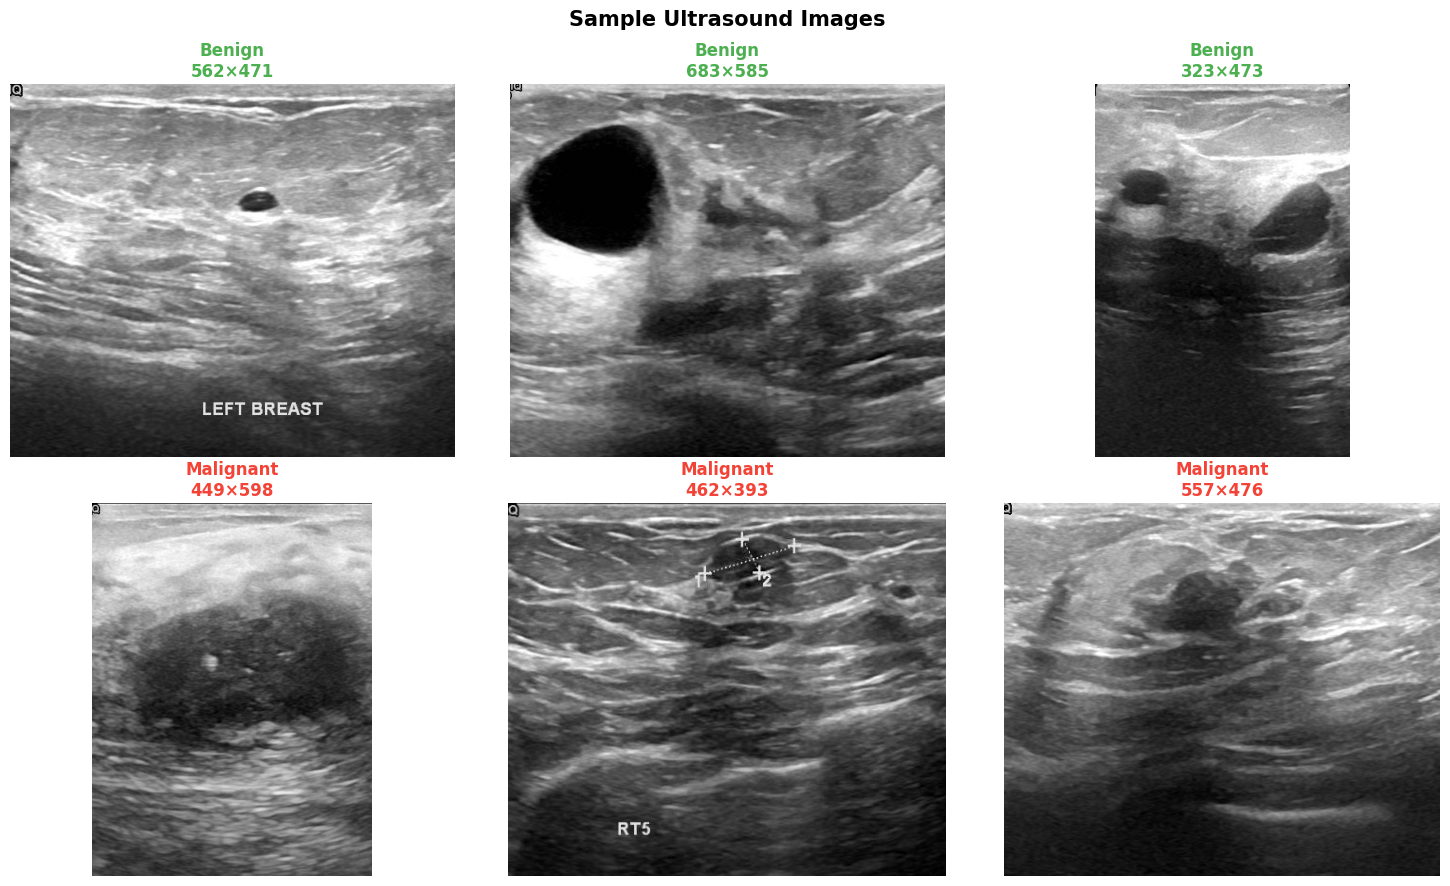

In [10]:
# Sample image grid — 3 benign + 3 malignant
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Sample Ultrasound Images', fontsize=15, fontweight='bold')

colors = {'benign': '#4CAF50', 'malignant': '#F44336'}

for row, cls in enumerate(CLASS_NAMES):
    imgs = sorted(os.listdir(f'{CLEAN_DIR}/{cls}'))[:3]
    for col, fname in enumerate(imgs):
        img = Image.open(f'{CLEAN_DIR}/{cls}/{fname}').convert('RGB')
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(f'{cls.capitalize()}\n{img.size[0]}×{img.size[1]}',
                                  color=colors[cls], fontweight='bold')
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

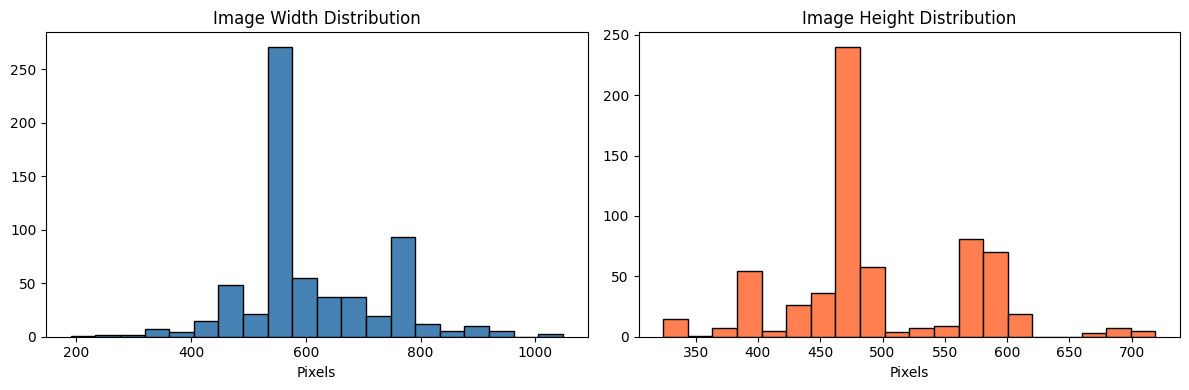

Width  — min: 190, max: 1048, mean: 608
Height — min: 324, max: 719, mean: 495


In [11]:
# Image size distribution
widths, heights = [], []
for cls in CLASS_NAMES:
    for fname in os.listdir(f'{CLEAN_DIR}/{cls}'):
        img = Image.open(f'{CLEAN_DIR}/{cls}/{fname}')
        widths.append(img.size[0])
        heights.append(img.size[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Image Width Distribution');  axes[0].set_xlabel('Pixels')
axes[1].hist(heights, bins=20, color='coral',    edgecolor='black')
axes[1].set_title('Image Height Distribution'); axes[1].set_xlabel('Pixels')
plt.tight_layout(); plt.show()
print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

---
## 🔄 Section 4 — Data Preprocessing & Augmentation

We split the cleaned dataset into **train (70%) / validation (15%) / test (15%)** and apply augmentation only to the training set.

In [12]:
from sklearn.model_selection import train_test_split

# Collect all image paths + labels
all_paths, all_labels = [], []
for label, cls in enumerate(CLASS_NAMES):
    for fname in os.listdir(f'{CLEAN_DIR}/{cls}'):
        all_paths.append(f'{CLEAN_DIR}/{cls}/{fname}')
        all_labels.append(cls)

# First split: 85% train+val, 15% test (stratified)
X_tv, X_test, y_tv, y_test = train_test_split(
    all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED)

# Second split: 70% train, 15% val (from the 85%)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1765, stratify=y_tv, random_state=SEED)  # 0.1765*0.85 ≈ 0.15

print(f'Train      : {len(X_train)} images  {Counter(y_train)}')
print(f'Validation : {len(X_val)}  images  {Counter(y_val)}')
print(f'Test       : {len(X_test)} images  {Counter(y_test)}')

Train      : 452 images  Counter({'benign': 305, 'malignant': 147})
Validation : 97  images  Counter({'benign': 66, 'malignant': 31})
Test       : 98 images  Counter({'benign': 66, 'malignant': 32})


In [13]:
# Copy splits into ImageDataGenerator-compatible folder structure
SPLIT_DIR = '/content/busi_split'

for split, paths, labels in [('train', X_train, y_train),
                               ('val',   X_val,   y_val),
                               ('test',  X_test,  y_test)]:
    for cls in CLASS_NAMES:
        os.makedirs(f'{SPLIT_DIR}/{split}/{cls}', exist_ok=True)
    for path, label in zip(paths, labels):
        dst = f'{SPLIT_DIR}/{split}/{label}/{os.path.basename(path)}'
        shutil.copy(path, dst)

print('✅ Split directories created.')

✅ Split directories created.


In [14]:
# ── Data Generators ───────────────────────────────────────────────────────────
# VGG16 preprocessing: scale pixels to [-1, 1] via preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    f'{SPLIT_DIR}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    f'{SPLIT_DIR}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    f'{SPLIT_DIR}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print('\nClass indices:', train_gen.class_indices)

# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced',
                           classes=np.array([0, 1]),
                           y=[train_gen.class_indices[l] for l in y_train])
class_weights = dict(enumerate(cw))
print('Class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in class_weights.items()})

Found 452 images belonging to 2 classes.
Found 97 images belonging to 2 classes.
Found 98 images belonging to 2 classes.

Class indices: {'benign': 0, 'malignant': 1}
Class weights: {'benign': np.float64(0.741), 'malignant': np.float64(1.537)}


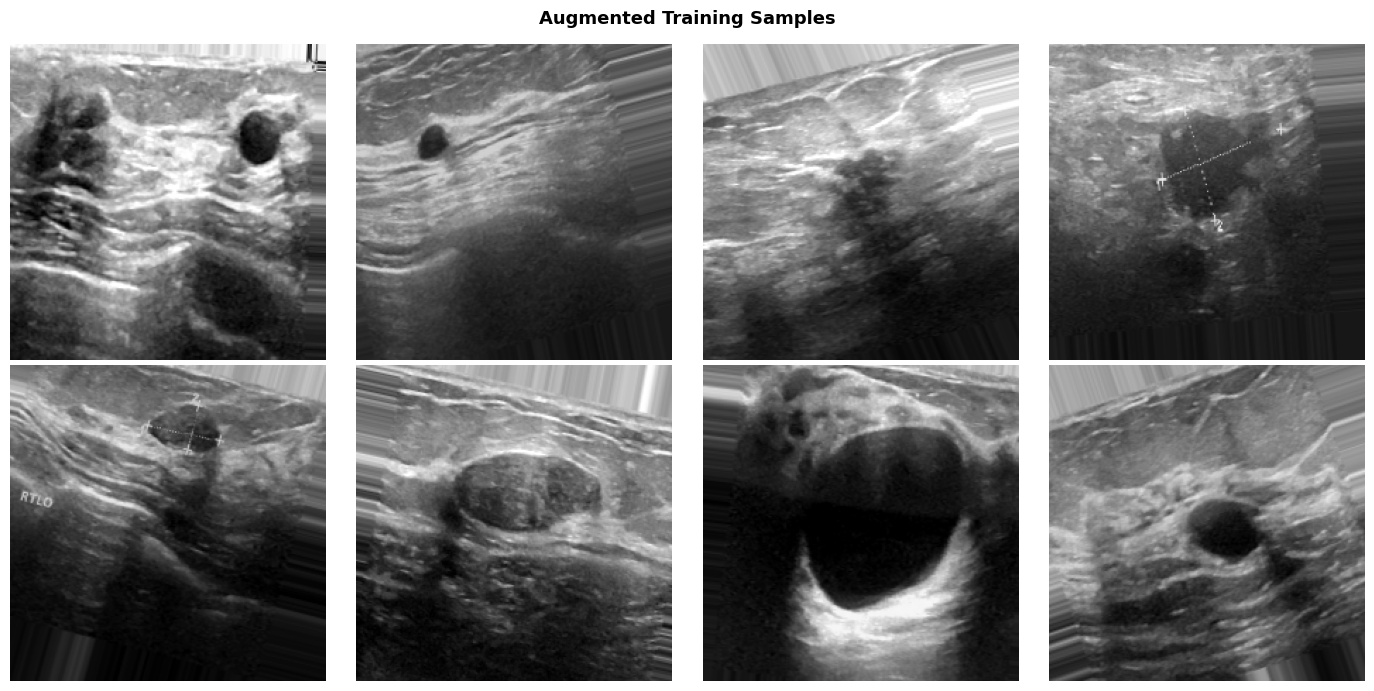

In [15]:
# Visualise augmented training samples
imgs, _ = next(train_gen)
# Reverse VGG16 preprocess for display
def deprocess(img):
    img = img.copy()
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    return np.clip(img[:, :, ::-1] / 255.0, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Augmented Training Samples', fontsize=13, fontweight='bold')
for ax, img in zip(axes.flatten(), imgs[:8]):
    ax.imshow(deprocess(img))
    ax.axis('off')
plt.tight_layout(); plt.show()

---
## 🏗️ Section 5 — Model Architecture (VGG16 Transfer Learning)

In [16]:
def build_model(fine_tune_at=None):
    """
    Build VGG16-based binary classifier.
    fine_tune_at: None  → all VGG16 layers frozen (Phase 1)
                 layer  → unfreeze from that layer onwards (Phase 2)
    """
    # Load VGG16 without top layers
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )

    if fine_tune_at is None:
        # Phase 1: freeze entire backbone
        base_model.trainable = False
    else:
        # Phase 2: unfreeze from fine_tune_at layer onwards
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    # Custom classification head
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=(fine_tune_at is not None))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

# --- Quick architecture summary (Phase 1 config) ---
model, base_model = build_model(fine_tune_at=None)
model.summary()

print(f'\nTrainable params (Phase 1): {model.count_params():,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,194 (56.76 MB)

 Trainable params: 164,994 (644.51 KB)

 Non-trainable params: 14,715,200 (56.13 MB)


Trainable params (Phase 1): 14,880,194


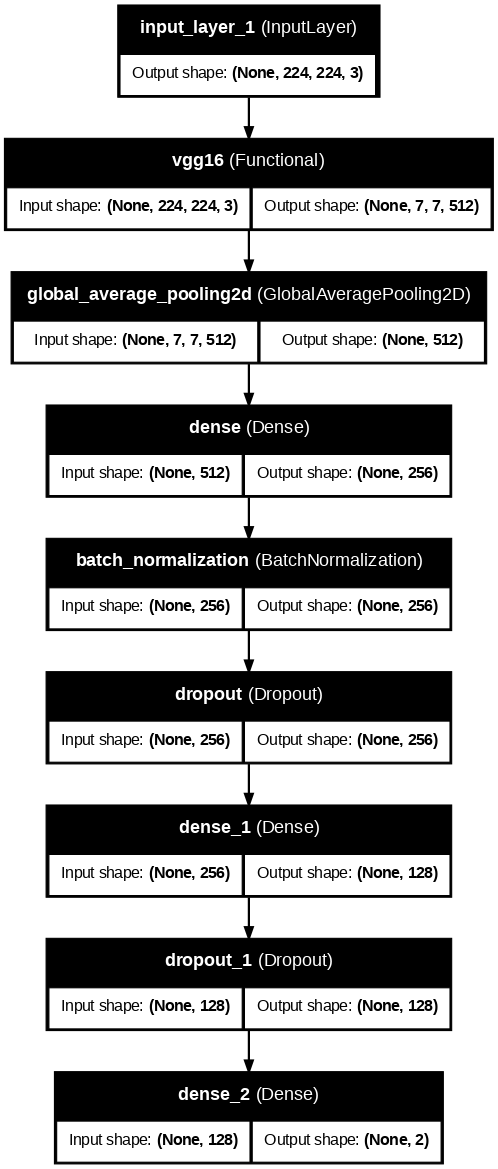

In [17]:
# Visualise model architecture
keras.utils.plot_model(model, show_shapes=True,
                        show_layer_names=True,
                        to_file='/content/model_architecture.png',
                        dpi=80)

from IPython.display import Image as IPImage
IPImage('/content/model_architecture.png')

---
## 🚀 Section 6 — Phase 1 Training: Feature Extraction

All VGG16 layers are **frozen**. Only the custom head is trained.

In [18]:
# Compile Phase 1
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model_p1.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('⏳ Starting Phase 1 training...')
history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P1,
    class_weight=class_weights,
    callbacks=callbacks_p1,
    verbose=1
)
print('\n✅ Phase 1 complete.')

⏳ Starting Phase 1 training...
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.5985 - auc: 0.6681 - loss: 1.0100 - precision: 0.5985 - recall: 0.5985
Epoch 1: val_accuracy improved from None to 0.68041, saving model to /content/best_model_p1.h5



Epoch 1: finished saving model to /content/best_model_p1.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6261 - auc: 0.6830 - loss: 0.9274 - precision: 0.6261 - recall: 0.6261 - val_accuracy: 0.6804 - val_auc: 0.8028 - val_loss: 1.1540 - val_precision: 0.6804 - val_recall: 0.6804 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6990 - auc: 0.7631 - loss: 0.7769 - precision: 0.6990 - recall: 0.6990
Epoch 2: val_accuracy did not improve from 0.68041
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 714ms/step - accuracy: 0.7035 - auc: 0.7748 - loss: 0.7233 - precision: 0.7035 - recall: 0.7035 - val_accuracy: 0.6701 - val_auc: 0.8208 - val_loss: 0.9951 - val_precision: 0.6701 - val_recall: 0.6701 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.7366 - auc: 0.8024 - loss: 0.6841 - precision: 0.7366 - recall: 0.7366
Epoch 3: val_accuracy improved from 0.68041 to 0.70103, saving model to /content/best_model_p1.h5



Epoch 3: finished saving model to /content/best_model_p1.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 742ms/step - accuracy: 0.7190 - auc: 0.7925 - loss: 0.7299 - precision: 0.7190 - recall: 0.7190 - val_accuracy: 0.7010 - val_auc: 0.8358 - val_loss: 1.0016 - val_precision: 0.7010 - val_recall: 0.7010 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.7176 - auc: 0.8087 - loss: 0.6580 - precision: 0.7176 - recall: 0.7176
Epoch 4: val_accuracy improved from 0.70103 to 0.72165, saving model to /content/best_model_p1.h5



Epoch 4: finished saving model to /content/best_model_p1.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 744ms/step - accuracy: 0.7102 - auc: 0.8128 - loss: 0.6565 - precision: 0.7102 - recall: 0.7102 - val_accuracy: 0.7216 - val_auc: 0.8501 - val_loss: 0.7145 - val_precision: 0.7216 - val_recall: 0.7216 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.7458 - auc: 0.8280 - loss: 0.6105 - precision: 0.7458 - recall: 0.7458
Epoch 5: val_accuracy improved from 0.72165 to 0.83505, saving model to /content/best_model_p1.h5



Epoch 5: finished saving model to /content/best_model_p1.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 748ms/step - accuracy: 0.7721 - auc: 0.8377 - loss: 0.5959 - precision: 0.7721 - recall: 0.7721 - val_accuracy: 0.8351 - val_auc: 0.9006 - val_loss: 0.4691 - val_precision: 0.8351 - val_recall: 0.8351 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.7670 - auc: 0.8518 - loss: 0.5619 - precision: 0.7670 - recall: 0.7670
Epoch 6: val_accuracy improved from 0.83505 to 0.85567, saving model to /content/best_model_p1.h5



Epoch 6: finished saving model to /content/best_model_p1.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 745ms/step - accuracy: 0.7456 - auc: 0.8325 - loss: 0.6112 - precision: 0.7456 - recall: 0.7456 - val_accuracy: 0.8557 - val_auc: 0.9098 - val_loss: 0.4434 - val_precision: 0.8557 - val_recall: 0.8557 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.7968 - auc: 0.8770 - loss: 0.5034 - precision: 0.7968 - recall: 0.7968
Epoch 7: val_accuracy did not improve from 0.85567
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 791ms/step - accuracy: 0.7942 - auc: 0.8691 - loss: 0.5124 - precision: 0.7942 - recall: 0.7942 - val_accuracy: 0.8144 - val_auc: 0.9193 - val_loss: 0.4185 - val_precision: 0.8144 - val_recall: 0.8144 - learning_rate: 0.0010
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.7531 - auc: 0.8619 - loss: 0.5254 - precision: 0.7531 - recall: 0.7531
Epoch 8: val_accuracy did not improve from 0.85567
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 702ms/step - accurac


Epoch 11: finished saving model to /content/best_model_p1.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 750ms/step - accuracy: 0.7788 - auc: 0.8749 - loss: 0.4759 - precision: 0.7788 - recall: 0.7788 - val_accuracy: 0.8763 - val_auc: 0.9512 - val_loss: 0.3345 - val_precision: 0.8763 - val_recall: 0.8763 - learning_rate: 0.0010
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.8108 - auc: 0.8785 - loss: 0.4758 - precision: 0.8108 - recall: 0.8108
Epoch 12: val_accuracy did not improve from 0.87629
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 738ms/step - accuracy: 0.8164 - auc: 0.8968 - loss: 0.4557 - precision: 0.8164 - recall: 0.8164 - val_accuracy: 0.8660 - val_auc: 0.9451 - val_loss: 0.3478 - val_precision: 0.8660 - val_recall: 0.8660 - learning_rate: 0.0010
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.8187 - auc: 0.8972 - loss: 0.4466 - precision: 0.8187 - recall: 0.8187
Epoch 13: val_accuracy did not improve from 0.87629
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 739ms/step - ac


Epoch 14: finished saving model to /content/best_model_p1.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 751ms/step - accuracy: 0.7898 - auc: 0.8911 - loss: 0.4633 - precision: 0.7898 - recall: 0.7898 - val_accuracy: 0.8866 - val_auc: 0.9285 - val_loss: 0.4025 - val_precision: 0.8866 - val_recall: 0.8866 - learning_rate: 0.0010
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.7665 - auc: 0.8373 - loss: 0.5650 - precision: 0.7665 - recall: 0.7665
Epoch 15: val_accuracy did not improve from 0.88660
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 724ms/step - accuracy: 0.7743 - auc: 0.8659 - loss: 0.5161 - precision: 0.7743 - recall: 0.7743 - val_accuracy: 0.8351 - val_auc: 0.9248 - val_loss: 0.4064 - val_precision: 0.8351 - val_recall: 0.8351 - learning_rate: 5.0000e-04
Epoch 16/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.8178 - auc: 0.9090 - loss: 0.4383 - precision: 0.8178 - recall: 0.8178
Epoch 16: val_accuracy did not improve from 0.88660
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 688ms/step 

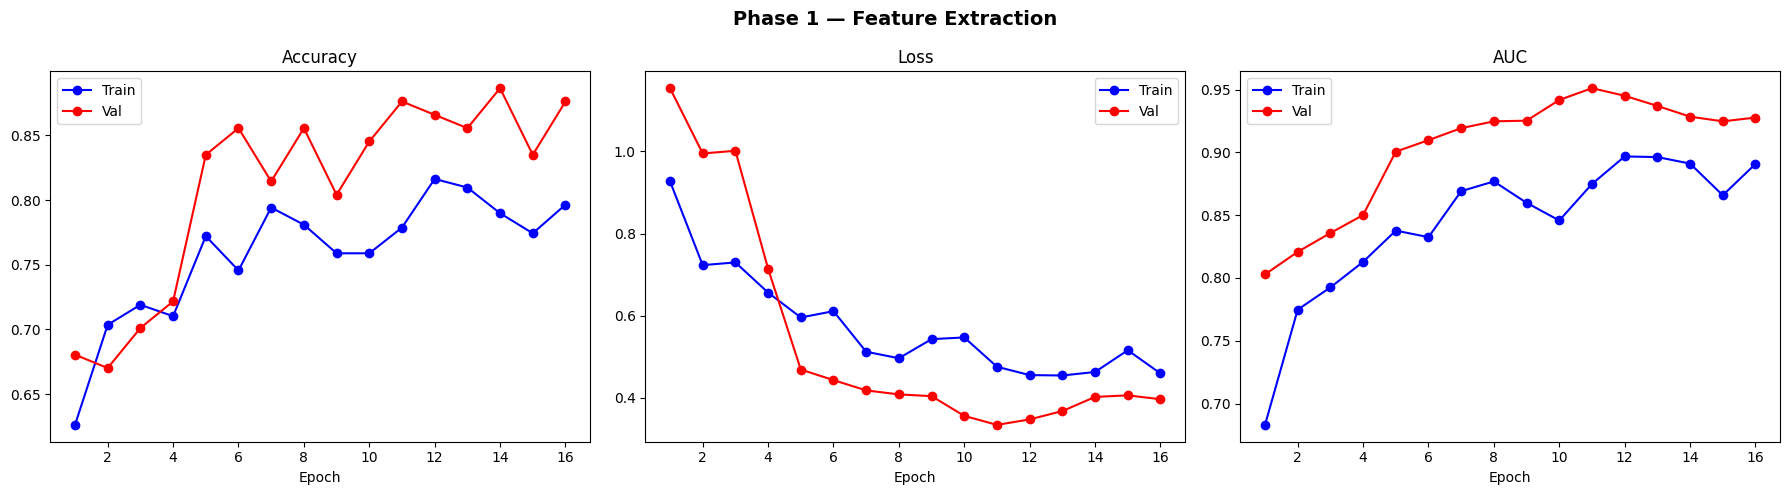

In [19]:
def plot_history(history, title='Training History', offset=0):
    epochs = range(1, len(history.history['accuracy']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs, history.history['accuracy'],    'b-o', label='Train')
    axes[0].plot(epochs, history.history['val_accuracy'],'r-o', label='Val')
    axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')

    # Loss
    axes[1].plot(epochs, history.history['loss'],    'b-o', label='Train')
    axes[1].plot(epochs, history.history['val_loss'],'r-o', label='Val')
    axes[1].set_title('Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

    # AUC
    axes[2].plot(epochs, history.history['auc'],    'b-o', label='Train')
    axes[2].plot(epochs, history.history['val_auc'],'r-o', label='Val')
    axes[2].set_title('AUC'); axes[2].legend(); axes[2].set_xlabel('Epoch')

    plt.tight_layout()
    plt.savefig(f'/content/{title.replace(" ","_")}.png', dpi=150)
    plt.show()

plot_history(history_p1, 'Phase 1 — Feature Extraction')

---
## 🔧 Section 7 — Phase 2 Training: Fine-Tuning

Unfreeze the **last convolutional block** of VGG16 (`block5`) and retrain with a lower learning rate.

In [20]:
# Print VGG16 layer names with indices for reference
for i, layer in enumerate(base_model.layers):
    print(f'{i:3d}  {layer.name:30s}  trainable={layer.trainable}')

  0  input_layer                     trainable=False
  1  block1_conv1                    trainable=False
  2  block1_conv2                    trainable=False
  3  block1_pool                     trainable=False
  4  block2_conv1                    trainable=False
  5  block2_conv2                    trainable=False
  6  block2_pool                     trainable=False
  7  block3_conv1                    trainable=False
  8  block3_conv2                    trainable=False
  9  block3_conv3                    trainable=False
 10  block3_pool                     trainable=False
 11  block4_conv1                    trainable=False
 12  block4_conv2                    trainable=False
 13  block4_conv3                    trainable=False
 14  block4_pool                     trainable=False
 15  block5_conv1                    trainable=False
 16  block5_conv2                    trainable=False
 17  block5_conv3                    trainable=False
 18  block5_pool                     trainable

In [21]:
# ── Phase 2: Fine-Tuning ─────────────────────────────────────────────────────
# Load the FULL model saved in Phase 1 (architecture + weights together)
model = keras.models.load_model('/content/best_model_p1.h5')

# Find the VGG16 base layer inside our functional model
base_model = model.layers[1]   # index 1 is the VGG16 sub-model
print(f'Base model name: {base_model.name}')

# Unfreeze block5 (last conv block) — layers 15 onward in VGG16
FINE_TUNE_AT = 15
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Confirm which layers are now trainable
print('\nTrainable layers after Phase 2 setup:')
for i, layer in enumerate(base_model.layers):
    print(f'  {i:3d}  {layer.name:30s}  trainable={layer.trainable}')

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # much smaller LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print(f'\nTrainable params (Phase 2): {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/content/best_model_p2.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('\n⏳ Starting Phase 2 fine-tuning...')
history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P2,
    class_weight=class_weights,
    callbacks=callbacks_p2,
    verbose=1
)
print('\n✅ Phase 2 complete.')

Base model name: vgg16

Trainable layers after Phase 2 setup:
    0  input_layer                     trainable=False
    1  block1_conv1                    trainable=False
    2  block1_conv2                    trainable=False
    3  block1_pool                     trainable=False
    4  block2_conv1                    trainable=False
    5  block2_conv2                    trainable=False
    6  block2_pool                     trainable=False
    7  block3_conv1                    trainable=False
    8  block3_conv2                    trainable=False
    9  block3_conv3                    trainable=False
   10  block3_pool                     trainable=False
   11  block4_conv1                    trainable=False
   12  block4_conv2                    trainable=False
   13  block4_conv3                    trainable=False
   14  block4_pool                     trainable=False
   15  block5_conv1                    trainable=True
   16  block5_conv2                    trainable=True
   17


Epoch 1: finished saving model to /content/best_model_p2.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7987 - auc: 0.8768 - loss: 0.5097 - precision: 0.7987 - recall: 0.7987 - val_accuracy: 0.8866 - val_auc: 0.9266 - val_loss: 0.4285 - val_precision: 0.8866 - val_recall: 0.8866 - learning_rate: 1.0000e-05
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8207 - auc: 0.9096 - loss: 0.4682 - precision: 0.8207 - recall: 0.8207
Epoch 2: val_accuracy did not improve from 0.88660
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 705ms/step - accuracy: 0.8031 - auc: 0.9042 - loss: 0.4457 - precision: 0.8031 - recall: 0.8031 - val_accuracy: 0.8763 - val_auc: 0.9286 - val_loss: 0.4226 - val_precision: 0.8763 - val_recall: 0.8763 - learning_rate: 1.0000e-05
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.8326 - auc: 0.9035 - loss: 0.4353 - precision: 0.8326 - recall: 0.8326
Epoch 3: val_accuracy did not improve from 0.88660
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 743ms/step - ac


Epoch 6: finished saving model to /content/best_model_p2.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 772ms/step - accuracy: 0.8584 - auc: 0.9347 - loss: 0.3668 - precision: 0.8584 - recall: 0.8584 - val_accuracy: 0.8969 - val_auc: 0.9430 - val_loss: 0.3996 - val_precision: 0.8969 - val_recall: 0.8969 - learning_rate: 1.0000e-05
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.8361 - auc: 0.9301 - loss: 0.3910 - precision: 0.8361 - recall: 0.8361
Epoch 7: val_accuracy did not improve from 0.89691
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 759ms/step - accuracy: 0.8562 - auc: 0.9360 - loss: 0.3712 - precision: 0.8562 - recall: 0.8562 - val_accuracy: 0.8866 - val_auc: 0.9494 - val_loss: 0.3658 - val_precision: 0.8866 - val_recall: 0.8866 - learning_rate: 1.0000e-05
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.8194 - auc: 0.9149 - loss: 0.3803 - precision: 0.8194 - recall: 0.8194
Epoch 8: val_accuracy did not improve from 0.89691
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 758ms/step -


Epoch 13: finished saving model to /content/best_model_p2.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 785ms/step - accuracy: 0.8783 - auc: 0.9530 - loss: 0.2979 - precision: 0.8783 - recall: 0.8783 - val_accuracy: 0.9072 - val_auc: 0.9680 - val_loss: 0.2852 - val_precision: 0.9072 - val_recall: 0.9072 - learning_rate: 1.0000e-05
Epoch 14/15
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.9122 - auc: 0.9637 - loss: 0.2777 - precision: 0.9122 - recall: 0.9122
Epoch 14: val_accuracy did not improve from 0.90722
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 752ms/step - accuracy: 0.9027 - auc: 0.9587 - loss: 0.2896 - precision: 0.9027 - recall: 0.9027 - val_accuracy: 0.8969 - val_auc: 0.9689 - val_loss: 0.2839 - val_precision: 0.8969 - val_recall: 0.8969 - learning_rate: 1.0000e-05
Epoch 15/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.8587 - auc: 0.9335 - loss: 0.3501 - precision: 0.8587 - recall: 0.8587
Epoch 15: val_accuracy did not improve from 0.90722
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 749ms/s

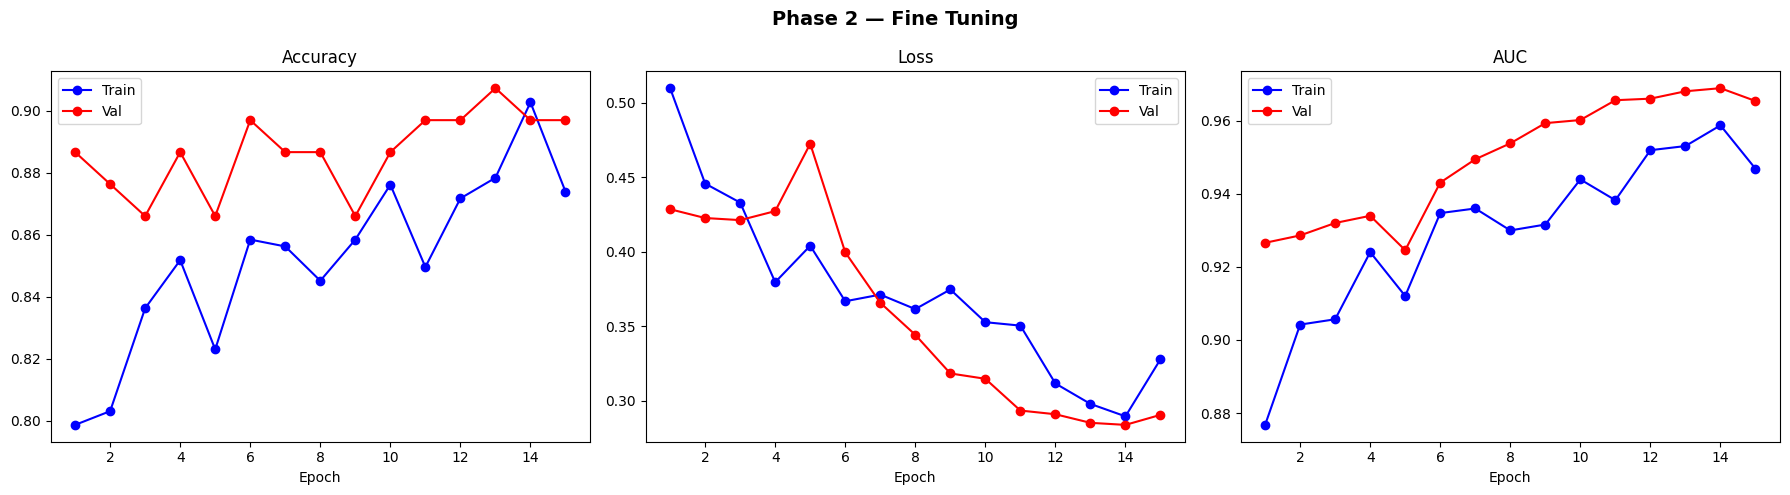

In [22]:
plot_history(history_p2, 'Phase 2 — Fine Tuning')

---
## 📈 Section 8 — Model Evaluation

Full evaluation on the held-out **test set** using all required metrics.

In [23]:
# Load the best model
model.load_weights('/content/best_model_p2.h5')

# Test set evaluation
test_gen.reset()
results = model.evaluate(test_gen, verbose=0)
metric_names = model.metrics_names

print('=' * 45)
print('          TEST SET EVALUATION RESULTS')
print('=' * 45)
for name, val in zip(metric_names, results):
    print(f'  {name:20s}: {val:.4f}')
print('=' * 45)

          TEST SET EVALUATION RESULTS
  loss                : 0.2965
  compile_metrics     : 0.8878


In [24]:
# Get predictions
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes

# Map indices back to class names
idx_to_class = {v: k for k, v in test_gen.class_indices.items()}

print('\n📊 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.94      0.89      0.91        66
   malignant       0.80      0.88      0.84        32

    accuracy                           0.89        98
   macro avg       0.87      0.88      0.88        98
weighted avg       0.89      0.89      0.89        98



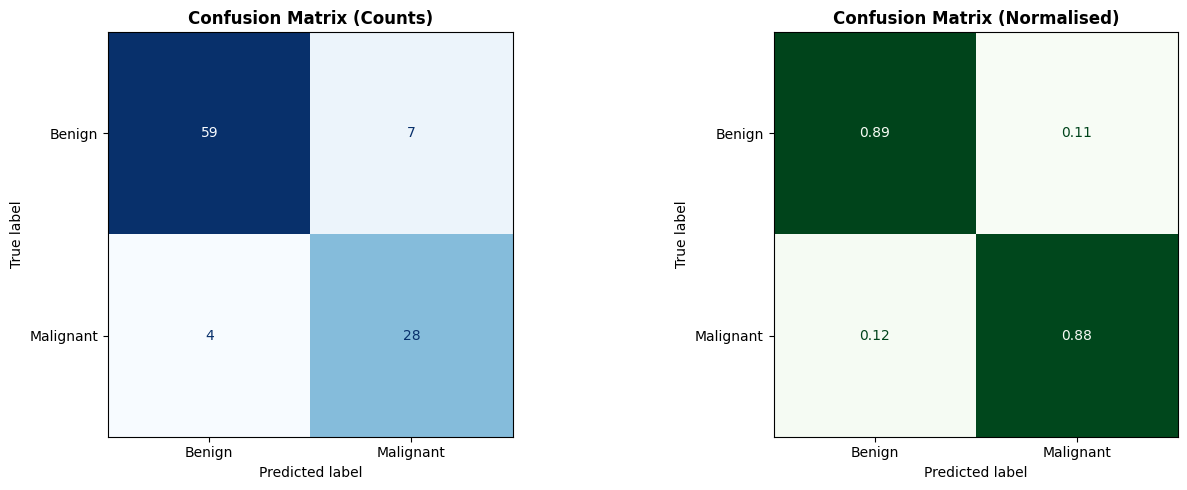

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(cm, display_labels=[c.capitalize() for c in CLASS_NAMES])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_n = ConfusionMatrixDisplay(np.round(cm_norm, 2),
                                 display_labels=[c.capitalize() for c in CLASS_NAMES])
disp_n.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

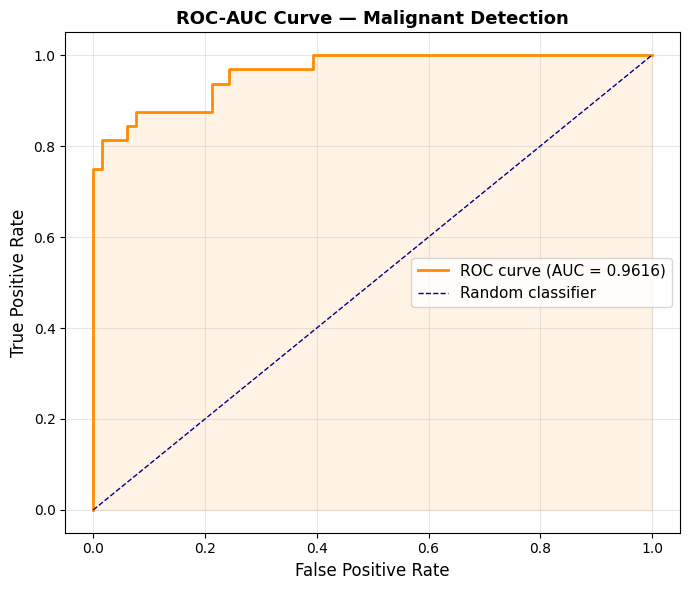


🎯 Final ROC-AUC Score: 0.9616


In [26]:
# ROC-AUC Curve
# y_pred_prob[:, 1] = probability of 'malignant'
malignant_idx = test_gen.class_indices['malignant']
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob[:, malignant_idx])
auc_score = roc_auc_score(y_true, y_pred_prob[:, malignant_idx])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('ROC-AUC Curve — Malignant Detection', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150)
plt.show()
print(f'\n🎯 Final ROC-AUC Score: {auc_score:.4f}')

In [27]:
# Per-class metric summary table
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_df = pd.DataFrame({
    'Class':     [c.capitalize() for c in CLASS_NAMES] + ['Weighted Avg'],
    'Precision': list(precision_score(y_true, y_pred, average=None).round(4)) +
                 [round(precision_score(y_true, y_pred, average='weighted'), 4)],
    'Recall':    list(recall_score(y_true, y_pred, average=None).round(4)) +
                 [round(recall_score(y_true, y_pred, average='weighted'), 4)],
    'F1-Score':  list(f1_score(y_true, y_pred, average=None).round(4)) +
                 [round(f1_score(y_true, y_pred, average='weighted'), 4)]
})

print('\n📋 Metrics Summary:')
print(metrics_df.to_string(index=False))


📋 Metrics Summary:
       Class  Precision  Recall  F1-Score
      Benign     0.9365  0.8939    0.9147
   Malignant     0.8000  0.8750    0.8358
Weighted Avg     0.8919  0.8878    0.8890


Total misclassified: 11 / 98


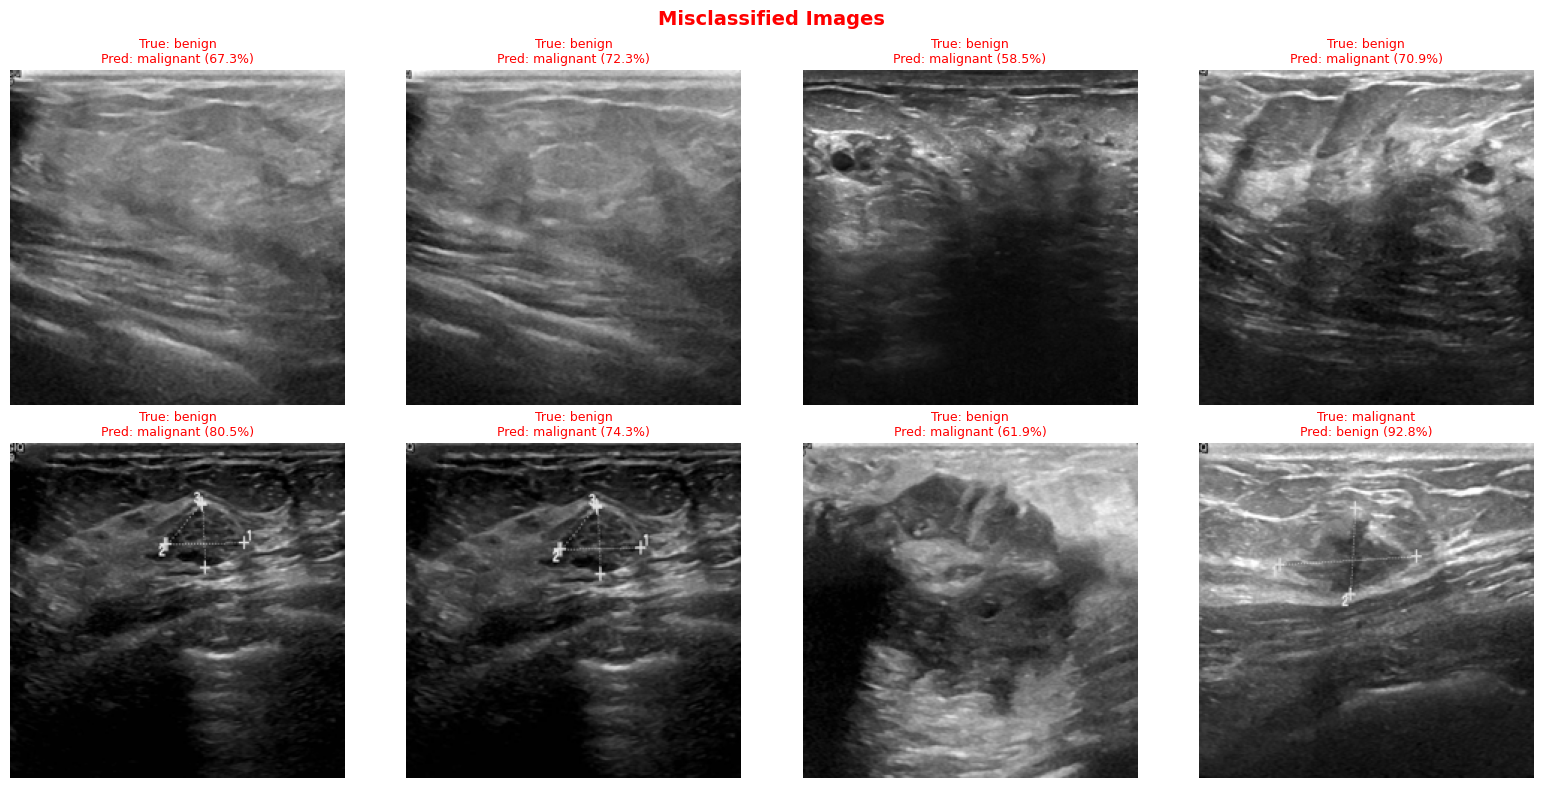

In [28]:
# Visualise prediction errors (misclassified images)
fnames        = test_gen.filenames
misclassified = np.where(y_pred != y_true)[0]

print(f'Total misclassified: {len(misclassified)} / {len(y_true)}')

n_show = min(8, len(misclassified))
if n_show > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Misclassified Images', fontsize=14, fontweight='bold', color='red')
    for ax, idx in zip(axes.flatten(), misclassified[:n_show]):
        img_path = os.path.join(f'{SPLIT_DIR}/test', fnames[idx])
        img = Image.open(img_path).resize(IMG_SIZE)
        true_label = idx_to_class[y_true[idx]]
        pred_label = idx_to_class[y_pred[idx]]
        conf = y_pred_prob[idx, y_pred[idx]] * 100
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.1f}%)',
                     color='red', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/misclassified.png', dpi=150)
    plt.show()

---
## 🔍 Section 9 — Prediction on New Images

Predicting on: malignant (80).png  (ground truth: malignant)


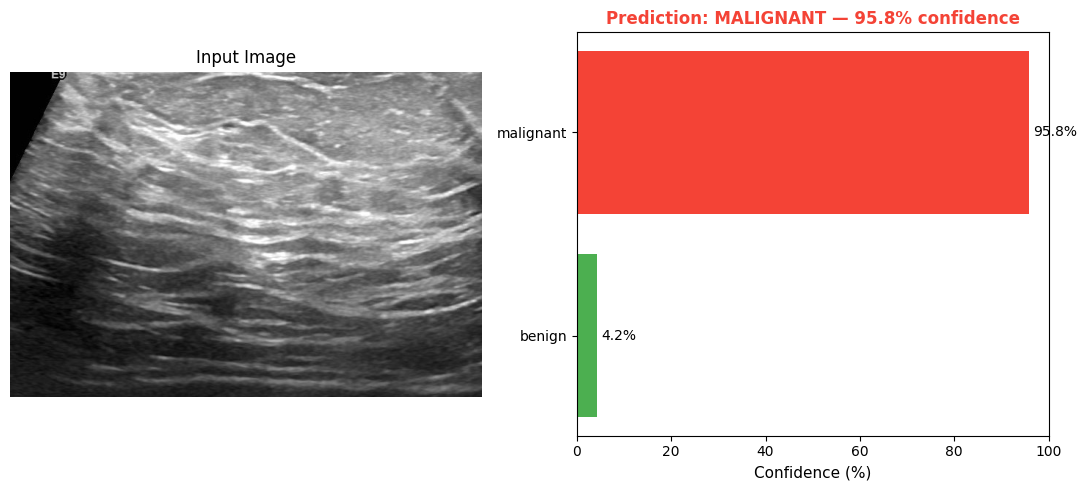

In [29]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

def predict_image(img_path, model, class_names=CLASS_NAMES):
    """
    Predict the class of a single breast ultrasound image.
    Returns: (predicted_class, confidence_percent, probabilities_dict)
    """
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32)
    arr = vgg_preprocess(arr)
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    return pred_class, confidence, {c: round(p * 100, 2) for c, p in zip(class_names, probs)}


def visualise_prediction(img_path, model):
    pred_class, confidence, all_probs = predict_image(img_path, model)

    img = Image.open(img_path).convert('RGB')

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    color = '#F44336' if pred_class == 'malignant' else '#4CAF50'

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Input Image', fontsize=12)
    axes[0].axis('off')

    bars = axes[1].barh(list(all_probs.keys()),
                        list(all_probs.values()),
                        color=['#4CAF50', '#F44336'])
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel('Confidence (%)', fontsize=11)
    axes[1].set_title(
        f'Prediction: {pred_class.upper()} — {confidence:.1f}% confidence',
        color=color, fontsize=12, fontweight='bold'
    )
    for bar, val in zip(bars, all_probs.values()):
        axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center')

    plt.tight_layout(); plt.show()
    return pred_class, confidence

# ── Demo: run prediction on a random test image ───────────────────────────────
sample_class = random.choice(CLASS_NAMES)
sample_dir   = f'{SPLIT_DIR}/test/{sample_class}'
sample_file  = random.choice(os.listdir(sample_dir))
sample_path  = f'{sample_dir}/{sample_file}'

print(f'Predicting on: {sample_file}  (ground truth: {sample_class})')
pred_class, confidence = visualise_prediction(sample_path, model)

Upload a breast ultrasound image to get a prediction:


Saving malignant (9).png to malignant (9).png


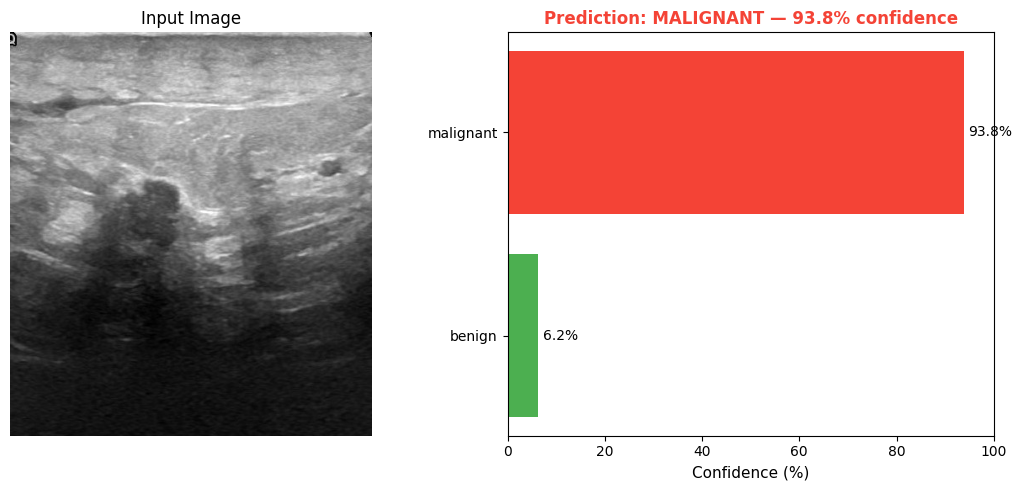

In [30]:
# ── Upload & predict your own image ──────────────────────────────────────────
print('Upload a breast ultrasound image to get a prediction:')
uploaded_img = files.upload()
if uploaded_img:
    user_img_path = list(uploaded_img.keys())[0]
    visualise_prediction(user_img_path, model)

---
## 💾 Section 10 — Save Model & Export

In [31]:
# Save in native Keras format (recommended for Keras 3)
MODEL_KERAS = '/content/breast_cancer_vgg16.keras'
model.save(MODEL_KERAS)
print(f'✅ Model saved to: {MODEL_KERAS}')

# Also keep an .h5 copy if needed for older pipelines
MODEL_H5 = '/content/breast_cancer_vgg16.h5'
model.save(MODEL_H5)
print(f'✅ H5 copy saved to: {MODEL_H5}')

# Export as SavedModel (for TFLite / TF Serving) — correct Keras 3 way
model.export('/content/breast_cancer_savedmodel')
print('✅ SavedModel export done.')

# Download both to your local machine
files.download(MODEL_KERAS)
files.download(MODEL_H5)
print('⬇️  Downloads started.')

✅ Model saved to: /content/breast_cancer_vgg16.keras
✅ H5 copy saved to: /content/breast_cancer_vgg16.h5
Saved artifact at '/content/breast_cancer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135172153937360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153937168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153938128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153947344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153939664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153940816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153938896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153940624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135172153940048: TensorSpec(sha

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloads started.


In [32]:
# (Optional) Save to Google Drive for persistence
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# shutil.copy(MODEL_PATH, '/content/drive/MyDrive/breast_cancer_vgg16.h5')
# print('✅ Model saved to Google Drive.')

---
## 🌐 Section 11 — Streamlit Web Application

Run the cell below to write the Streamlit app to disk, then use `localtunnel` or `ngrok` to expose it publicly from Colab.

> **To run the app locally:**  
> 1. Download `app.py` and `breast_cancer_vgg16.h5` to the same folder  
> 2. `pip install streamlit tensorflow pillow`  
> 3. `streamlit run app.py`

In [37]:
APP_CODE = '''
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input
import os
import time
import mysql.connector
from mysql.connector import Error
import pandas as pd
from datetime import datetime
import hashlib
from huggingface_hub import hf_hub_download

# ══════════════════════════════════════════════════════════════════════════════
#  PAGE CONFIG
# ══════════════════════════════════════════════════════════════════════════════
st.set_page_config(
    page_title="Breast Cancer Detection System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# ══════════════════════════════════════════════════════════════════════════════
#  CUSTOM CSS
# ══════════════════════════════════════════════════════════════════════════════
st.markdown("""
<style>
    .role-badge-admin {
        background: linear-gradient(90deg,#e94560,#c0392b);
        color:white; padding:4px 12px; border-radius:20px;
        font-size:12px; font-weight:600;
    }
    .role-badge-doctor {
        background: linear-gradient(90deg,#2980b9,#1a5276);
        color:white; padding:4px 12px; border-radius:20px;
        font-size:12px; font-weight:600;
    }
    .role-badge-radiologist {
        background: linear-gradient(90deg,#27ae60,#1e8449);
        color:white; padding:4px 12px; border-radius:20px;
        font-size:12px; font-weight:600;
    }
    .role-badge-researcher {
        background: linear-gradient(90deg,#8e44ad,#6c3483);
        color:white; padding:4px 12px; border-radius:20px;
        font-size:12px; font-weight:600;
    }
    .welcome-card {
        background: linear-gradient(135deg,#1a1a2e,#16213e);
        border:1px solid #2d3748; border-radius:12px;
        padding:16px 20px; margin-bottom:20px;
    }
</style>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════════════════════
#  CONSTANTS
# ══════════════════════════════════════════════════════════════════════════════
IMG_SIZE    = (224, 224)
CLASS_NAMES = ["benign", "malignant"]

# Load model from Hugging Face if not already downloaded locally
MODEL_PATH = "breast_cancer_vgg16.keras"
if not os.path.exists(MODEL_PATH):
    with st.spinner("Downloading model from Hugging Face... (first run only)"):
        MODEL_PATH = hf_hub_download(
            repo_id="iman0642/breast-cancer-vgg16",
            filename="breast_cancer_vgg16.keras"
        )

ROLE_ICONS = {
    "admin":       "👑",
    "doctor":      "👨‍⚕️",
    "radiologist": "🔬",
    "researcher":  "🧪"
}

# ══════════════════════════════════════════════════════════════════════════════
#  DATABASE CONFIG  (uses environment variables for deployment)
# ══════════════════════════════════════════════════════════════════════════════
DB_CONFIG = {
    "host":     os.getenv("DB_HOST",     "localhost"),
    "user":     os.getenv("DB_USER",     "root"),
    "password": os.getenv("DB_PASSWORD", "admin"),
    "database": os.getenv("DB_NAME",     "breast_cancer_db")
}

def get_connection(silent=False):
    try:
        return mysql.connector.connect(**DB_CONFIG)
    except Error as e:
        if not silent:
            st.session_state["db_last_error"] = str(e)
        return None

def _column_exists(cur, table, column):
    cur.execute("""
        SELECT COUNT(*) FROM information_schema.COLUMNS
        WHERE TABLE_SCHEMA = %s AND TABLE_NAME = %s AND COLUMN_NAME = %s
    """, (DB_CONFIG["database"], table, column))
    return cur.fetchone()[0] > 0

def migrate_schema(cur):
    if not _column_exists(cur, "prediction_logs", "reviewed_by"):
        cur.execute("ALTER TABLE prediction_logs ADD COLUMN reviewed_by INT NULL")
    if not _column_exists(cur, "prediction_logs", "created_by"):
        cur.execute("ALTER TABLE prediction_logs ADD COLUMN created_by INT NULL")
    if not _column_exists(cur, "prediction_logs", "image_id"):
        cur.execute("ALTER TABLE prediction_logs ADD COLUMN image_id INT NULL")
    if not _column_exists(cur, "prediction_logs", "processing_time_ms"):
        cur.execute("ALTER TABLE prediction_logs ADD COLUMN processing_time_ms INT NULL")

# ══════════════════════════════════════════════════════════════════════════════
#  DATABASE INIT
# ══════════════════════════════════════════════════════════════════════════════
def init_db():
    conn = get_connection(silent=True)
    if not conn:
        return False, "Could not connect to MySQL. Is the server running?"
    cur = conn.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS users (
            user_id       INT           NOT NULL AUTO_INCREMENT,
            username      VARCHAR(100)  NOT NULL UNIQUE,
            full_name     VARCHAR(255)  NOT NULL,
            email         VARCHAR(255)  NOT NULL UNIQUE,
            role          ENUM('admin','doctor','radiologist','researcher')
                          NOT NULL DEFAULT 'doctor',
            password_hash VARCHAR(64),
            created_at    DATETIME      NOT NULL DEFAULT CURRENT_TIMESTAMP,
            is_active     TINYINT(1)    NOT NULL DEFAULT 1,
            PRIMARY KEY (user_id)
        ) ENGINE=InnoDB;
    """)

    cur.execute("""
        CREATE TABLE IF NOT EXISTS images_metadata (
            image_id          INT          NOT NULL AUTO_INCREMENT,
            image_name        VARCHAR(255) NOT NULL,
            original_filename VARCHAR(255) NOT NULL,
            file_size_kb      FLOAT,
            image_width_px    INT,
            image_height_px   INT,
            file_format       ENUM('JPEG','PNG','BMP','TIFF') NOT NULL DEFAULT 'PNG',
            upload_path       VARCHAR(500),
            uploaded_by       INT,
            uploaded_at       DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP,
            notes             TEXT,
            PRIMARY KEY (image_id),
            CONSTRAINT fk_image_user
                FOREIGN KEY (uploaded_by) REFERENCES users(user_id)
                ON DELETE SET NULL
        ) ENGINE=InnoDB;
    """)

    cur.execute("""
        CREATE TABLE IF NOT EXISTS prediction_logs (
            id                 INT          NOT NULL AUTO_INCREMENT,
            image_id           INT,
            image_name         VARCHAR(255) NOT NULL,
            predicted_class    ENUM('Benign','Malignant') NOT NULL,
            confidence_score   FLOAT        NOT NULL,
            model_version      VARCHAR(50)  NOT NULL DEFAULT 'VGG16-v1',
            processing_time_ms INT,
            is_verified        TINYINT(1)   NOT NULL DEFAULT 0,
            notes              TEXT,
            reviewed_by        INT          NULL,
            created_by         INT          NULL,
            timestamp          DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP,
            PRIMARY KEY (id),
            CONSTRAINT fk_pred_image
                FOREIGN KEY (image_id) REFERENCES images_metadata(image_id)
                ON DELETE SET NULL,
            CONSTRAINT fk_pred_reviewer
                FOREIGN KEY (reviewed_by) REFERENCES users(user_id)
                ON DELETE SET NULL,
            CHECK (confidence_score BETWEEN 0.0 AND 1.0)
        ) ENGINE=InnoDB;
    """)

    migrate_schema(cur)

    demo_users = [
        ("admin",        "Admin User",          "admin@hospital.com",       "admin"),
        ("doctor1",      "Dr. Tayyaba Akhtar",  "tayyaba@hospital.com",     "doctor"),
        ("dr_aiman",     "Dr. Aiman Ijaz",      "aiman@hospital.com",       "radiologist"),
        ("researcher1",  "Researcher One",       "research@hospital.com",    "researcher"),
        ("dr_sarah",     "Dr. Sarah Ahmed",      "sarah@medcenter.pk",       "doctor"),
        ("dr_kamran",    "Dr. Kamran Malik",     "kamran@medcenter.pk",      "radiologist"),
        ("dr_nadia",     "Dr. Nadia Hussain",    "nadia@medcenter.pk",       "doctor"),
        ("admin_ali",    "Ali Hassan",           "ali@medcenter.pk",         "admin"),
    ]
    for uname, fname, email, role in demo_users:
        pwd_hash = hashlib.sha256(uname.encode()).hexdigest()
        cur.execute("""
            INSERT IGNORE INTO users
                (username, full_name, email, role, password_hash)
            VALUES (%s, %s, %s, %s, %s)
        """, (uname, fname, email, role, pwd_hash))
        cur.execute("""
            UPDATE users
            SET password_hash = %s
            WHERE username = %s
              AND (password_hash IS NULL OR password_hash = '')
        """, (pwd_hash, uname))

    conn.commit()
    cur.close()
    conn.close()
    return True, ""

def refresh_db_status():
    conn = get_connection(silent=True)
    if conn:
        try:
            cur = conn.cursor()
            migrate_schema(cur)
            conn.commit()
            cur.close()
        finally:
            conn.close()
        st.session_state["db_ok"]  = True
        st.session_state["db_err"] = ""
        return True
    err = st.session_state.get("db_last_error", "MySQL unreachable")
    st.session_state["db_ok"]  = False
    st.session_state["db_err"] = err
    return False

if "db_ok" not in st.session_state:
    _ok, _err = init_db()
    st.session_state["db_ok"]  = _ok
    st.session_state["db_err"] = _err

DB_OK  = st.session_state["db_ok"]
DB_ERR = st.session_state.get("db_err", "")

# ══════════════════════════════════════════════════════════════════════════════
#  AUTH FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
def login_user(username, password):
    conn = get_connection(silent=True)
    if not conn:
        return None
    try:
        cur = conn.cursor(dictionary=True)
        pwd_hash = hashlib.sha256(password.encode()).hexdigest()
        cur.execute("""
            SELECT user_id, username, full_name, email, role
            FROM users
            WHERE username = %s
              AND password_hash = %s
              AND is_active = 1
        """, (username, pwd_hash))
        return cur.fetchone()
    except Error:
        return None
    finally:
        conn.close()

def get_all_users():
    conn = get_connection(silent=True)
    if not conn:
        return pd.DataFrame()
    try:
        return pd.read_sql("""
            SELECT user_id, username, full_name, email,
                   role, created_at,
                   CASE WHEN is_active=1 THEN 'Active' ELSE 'Inactive' END AS status
            FROM users ORDER BY created_at DESC
        """, conn)
    finally:
        conn.close()

def add_user(username, full_name, email, role, password):
    conn = get_connection(silent=True)
    if not conn:
        return False
    try:
        cur = conn.cursor()
        pwd_hash = hashlib.sha256(password.encode()).hexdigest()
        cur.execute("""
            INSERT INTO users (username, full_name, email, role, password_hash)
            VALUES (%s, %s, %s, %s, %s)
        """, (username, full_name, email, role, pwd_hash))
        conn.commit()
        return True
    except Error as e:
        st.error(f"Add user failed: {e}")
        return False
    finally:
        conn.close()

def deactivate_user(user_id):
    conn = get_connection(silent=True)
    if not conn:
        return False
    try:
        cur = conn.cursor()
        cur.execute("UPDATE users SET is_active=0 WHERE user_id=%s", (user_id,))
        conn.commit()
        return True
    finally:
        conn.close()

# ══════════════════════════════════════════════════════════════════════════════
#  CRUD FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
def db_insert_prediction(image_name, predicted_class, confidence_score,
                         user_id=None, file_size_kb=None,
                         image_width_px=None, image_height_px=None,
                         processing_time_ms=None):
    conn = get_connection(silent=True)
    if not conn:
        return None
    cur = conn.cursor()

    cur.execute("""
        INSERT INTO images_metadata
            (image_name, original_filename, file_size_kb,
             image_width_px, image_height_px, file_format, uploaded_by)
        VALUES (%s, %s, %s, %s, %s, 'PNG', %s)
    """, (image_name, image_name, file_size_kb,
          image_width_px, image_height_px, user_id))
    image_id = cur.lastrowid

    cur.execute("""
        INSERT INTO prediction_logs
            (image_id, image_name, predicted_class, confidence_score,
             processing_time_ms, created_by)
        VALUES (%s, %s, %s, %s, %s, %s)
    """, (image_id, image_name, predicted_class,
          round(confidence_score, 4), processing_time_ms, user_id))

    conn.commit()
    new_id = cur.lastrowid
    cur.close()
    conn.close()
    return new_id

def db_get_all(filter_class=None, min_conf=0.0, only_unverified=False):
    conn = get_connection(silent=True)
    if not conn:
        return None
    cur = conn.cursor(dictionary=True)
    where_plain = ["confidence_score >= %s"]
    params = [min_conf]
    if filter_class and filter_class != "All":
        where_plain.append("predicted_class = %s")
        params.append(filter_class)
    if only_unverified:
        where_plain.append("is_verified = 0")
    where_prefixed = " AND ".join(
        c.replace("confidence_score", "p.confidence_score")
         .replace("predicted_class", "p.predicted_class")
         .replace("is_verified", "p.is_verified")
        for c in where_plain
    )
    try:
        cur.execute(f"""
            SELECT p.id, p.image_name, p.predicted_class,
                   ROUND(p.confidence_score*100,2) AS confidence_pct,
                   p.model_version, p.is_verified, p.notes,
                   COALESCE(u_save.full_name, u_rev.full_name) AS saved_by,
                   p.timestamp
            FROM prediction_logs p
            LEFT JOIN users u_save ON p.created_by  = u_save.user_id
            LEFT JOIN users u_rev  ON p.reviewed_by = u_rev.user_id
            WHERE {where_prefixed}
            ORDER BY p.timestamp DESC
        """, params)
    except Error:
        where_sql = " AND ".join(where_plain)
        cur.execute(f"""
            SELECT id, image_name, predicted_class,
                   ROUND(confidence_score*100,2) AS confidence_pct,
                   model_version, is_verified, notes,
                   NULL AS saved_by, timestamp
            FROM prediction_logs
            WHERE {where_sql}
            ORDER BY timestamp DESC
        """, params)
    rows = cur.fetchall()
    cur.close()
    conn.close()
    return rows

def db_get_by_id(pred_id):
    conn = get_connection(silent=True)
    if not conn:
        return None
    cur  = conn.cursor(dictionary=True)
    cur.execute("SELECT * FROM prediction_logs WHERE id=%s", (pred_id,))
    row = cur.fetchone()
    cur.close()
    conn.close()
    return row

def db_summary():
    conn = get_connection(silent=True)
    if not conn:
        return []
    cur  = conn.cursor(dictionary=True)
    cur.execute("""
        SELECT
            predicted_class,
            COUNT(*)                            AS total,
            SUM(is_verified)                    AS verified,
            COUNT(*) - SUM(is_verified)         AS pending,
            ROUND(AVG(confidence_score)*100,2)  AS avg_conf_pct
        FROM prediction_logs
        GROUP BY predicted_class
    """)
    rows = cur.fetchall()
    cur.close()
    conn.close()
    return rows

def db_update_prediction(pred_id, new_class, new_conf, notes, reviewer_id=None):
    conn = get_connection(silent=True)
    if not conn:
        return 0
    cur  = conn.cursor()
    cur.execute("""
        UPDATE prediction_logs
        SET predicted_class  = %s,
            confidence_score = %s,
            notes            = %s,
            is_verified      = 1,
            reviewed_by      = COALESCE(%s, reviewed_by)
        WHERE id = %s
    """, (new_class, round(new_conf / 100, 4), notes, reviewer_id, pred_id))
    conn.commit()
    affected = cur.rowcount
    cur.close()
    conn.close()
    return affected

def db_delete_prediction(pred_id):
    conn = get_connection(silent=True)
    if not conn:
        return 0
    cur  = conn.cursor()
    cur.execute("DELETE FROM prediction_logs WHERE id=%s", (pred_id,))
    conn.commit()
    affected = cur.rowcount
    cur.close()
    conn.close()
    return affected

def db_delete_unverified_low_conf(threshold):
    conn = get_connection(silent=True)
    if not conn:
        return 0
    cur  = conn.cursor()
    cur.execute("""
        DELETE FROM prediction_logs
        WHERE is_verified=0 AND confidence_score < %s
    """, (threshold / 100,))
    conn.commit()
    affected = cur.rowcount
    cur.close()
    conn.close()
    return affected

# ══════════════════════════════════════════════════════════════════════════════
#  MODEL
# ══════════════════════════════════════════════════════════════════════════════
@st.cache_resource
def load_my_model():
    return tf.keras.models.load_model(MODEL_PATH)

def is_mask_image(img):
    arr = np.array(img.convert("L"))
    if len(np.unique(arr)) <= 5:
        return True
    if np.sum(arr < 10) / arr.size > 0.95:
        return True
    return False

def predict(img_array, model):
    start = time.time()
    arr   = np.array(img_array.resize(IMG_SIZE).convert("RGB"), dtype=np.float32)
    arr   = preprocess_input(arr)
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    elapsed_ms = int((time.time() - start) * 1000)
    pred_idx   = int(np.argmax(probs))
    return CLASS_NAMES[pred_idx], float(probs[pred_idx]) * 100, probs, elapsed_ms

# ══════════════════════════════════════════════════════════════════════════════
#  SESSION STATE INIT
# ══════════════════════════════════════════════════════════════════════════════
if "logged_in" not in st.session_state:
    st.session_state.logged_in = False
    st.session_state.user      = None

# ══════════════════════════════════════════════════════════════════════════════
#  LOGIN PAGE
# ══════════════════════════════════════════════════════════════════════════════
def show_login():
    col1, col2, col3 = st.columns([1, 1.1, 1])
    with col2:
        st.markdown("""
        <div style='text-align:center; margin-top:40px; margin-bottom:30px;'>
            <div style='font-size:64px;'>🩺</div>
            <h1 style='color:#ffffff; font-size:30px; font-weight:700; margin:10px 0 4px;'>
                Breast Cancer Detection
            </h1>
            <p style='color:#a0aec0; font-size:15px; margin:0;'>
                AI-Powered Diagnostic System
            </p>
            <p style='color:#718096; font-size:12px; margin-top:6px;'>
                VGG16 Transfer Learning &nbsp;·&nbsp; BUSI Dataset &nbsp;·&nbsp; MySQL
            </p>
        </div>
        """, unsafe_allow_html=True)

        with st.container(border=True):
            st.markdown("#### 🔐 Sign In to Your Account")
            st.markdown("")
            username = st.text_input("👤  Username", placeholder="Enter your username")
            password = st.text_input("🔑  Password", type="password",
                                      placeholder="Enter your password")
            st.markdown("")
            if st.button("Sign In →", type="primary", use_container_width=True):
                if not username or not password:
                    st.error("Please enter both username and password.")
                else:
                    with st.spinner("Authenticating..."):
                        user = login_user(username, password)
                    if user:
                        st.session_state.logged_in = True
                        st.session_state.user      = user
                        st.success(f"Welcome, {user['full_name']}!")
                        time.sleep(1)
                        st.rerun()
                    else:
                        st.error("❌ Invalid username or password.")

        st.markdown("")
        with st.expander("👥 Demo Credentials (click to view)"):
            st.markdown("""
            | Role | Username | Password |
            |------|----------|----------|
            | 👑 Admin | `admin` | `admin` |
            | 👨‍⚕️ Doctor | `doctor1` | `doctor1` |
            | 🔬 Radiologist | `dr_aiman` | `dr_aiman` |
            | 🧪 Researcher | `researcher1` | `researcher1` |
            """)
            st.caption("Password is the same as username for all demo accounts.")

        st.markdown("""
        <p style='text-align:center; color:#4a5568; font-size:11px; margin-top:16px;'>
            ⚠️ For educational and research use only.<br>
            Not a substitute for professional medical diagnosis.
        </p>
        """, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════════════════════
#  SIDEBAR
# ══════════════════════════════════════════════════════════════════════════════
def show_sidebar():
    user = st.session_state.user
    role = user["role"]
    icon = ROLE_ICONS.get(role, "👤")

    with st.sidebar:
        st.markdown(f"""
        <div class='welcome-card'>
            <div style='font-size:40px; text-align:center;'>{icon}</div>
            <div style='text-align:center; color:white; font-weight:600;
                        font-size:16px; margin:8px 0 4px;'>{user['full_name']}</div>
            <div style='text-align:center; color:#a0aec0;
                        font-size:12px; margin-bottom:10px;'>@{user['username']}</div>
            <div style='text-align:center;'>
                <span class='role-badge-{role}'>{icon} {role.capitalize()}</span>
            </div>
        </div>
        """, unsafe_allow_html=True)

        st.divider()

        if refresh_db_status():
            st.success("🟢 MySQL Connected")
        else:
            err = st.session_state.get("db_err") or st.session_state.get("db_last_error", "Unknown")
            st.error(f"🔴 MySQL Error\n{err}")

        st.markdown("**Model:** VGG16 Transfer Learning")
        st.markdown("**Dataset:** BUSI (780 images)")
        st.markdown("**Classes:** Benign | Malignant")
        st.divider()

        st.markdown("#### 🗂️ Navigation")
        pages = ["🔬 Predict & Save", "📋 View History", "📊 Dashboard"]

        if role in ["doctor", "radiologist", "admin"]:
            pages.append("✏️ Update / Verify")

        if role == "admin":
            pages.append("🗑️ Delete Records")
            pages.append("👥 Manage Users")

        page = st.radio("", pages, label_visibility="collapsed")
        st.divider()

        if st.button("🚪 Sign Out", use_container_width=True):
            st.session_state.logged_in = False
            st.session_state.user      = None
            st.rerun()

        st.markdown(f"""
        <p style='text-align:center; color:#4a5568; font-size:10px; margin-top:16px;'>
            Logged in as <b>{role}</b><br>
            {datetime.now().strftime('%Y-%m-%d %H:%M')}
        </p>
        """, unsafe_allow_html=True)

    return page

# ══════════════════════════════════════════════════════════════════════════════
#  PAGE — PREDICT & SAVE
# ══════════════════════════════════════════════════════════════════════════════
def page_predict():
    user = st.session_state.user
    st.title("🔬 Predict & Save")
    st.markdown("Upload a breast ultrasound image to classify and save to database.")
    st.divider()

    upload_col, result_col = st.columns([1, 1], gap="large")

    with upload_col:
        st.subheader("📤 Upload Image")
        uploaded = st.file_uploader(
            "Choose a PNG or JPG ultrasound image",
            type=["png", "jpg", "jpeg"]
        )
        if uploaded:
            img = Image.open(uploaded)

            if is_mask_image(img):
                st.error("⛔ This looks like a mask image, not a real ultrasound!")
                st.warning("Please upload the original image, not the _mask version.")
                return

            st.image(img, caption="Uploaded Image", use_container_width=True)
            st.markdown(f"**File:** {uploaded.name}")
            st.markdown(f"**Size:** {round(uploaded.size/1024, 2)} KB")
            st.markdown(f"**Resolution:** {img.size[0]} × {img.size[1]} px")

    with result_col:
        st.subheader("🔍 Prediction")
        if uploaded:
            with st.spinner("Analysing image..."):
                model = load_my_model()
                pred_class, confidence, probs, elapsed_ms = predict(img, model)

            color = "🔴" if pred_class == "malignant" else "🟢"
            st.markdown(f"### {color} {pred_class.upper()}")
            st.metric("Confidence", f"{confidence:.1f}%")
            st.progress(int(confidence))
            st.caption(f"⏱️ Processing time: {elapsed_ms} ms")

            st.divider()
            st.markdown("**Class Probabilities:**")
            for cls, prob in zip(CLASS_NAMES, probs):
                bc = "🔴" if cls == "malignant" else "🟢"
                st.markdown(f"{bc} **{cls.capitalize()}:** {prob*100:.2f}%")
                st.progress(float(prob))

            st.divider()

            if refresh_db_status():
                db_class = pred_class.capitalize()
                new_id   = db_insert_prediction(
                    image_name         = uploaded.name,
                    predicted_class    = db_class,
                    confidence_score   = confidence / 100,
                    user_id            = user["user_id"],
                    file_size_kb       = round(uploaded.size / 1024, 2),
                    image_width_px     = img.size[0],
                    image_height_px    = img.size[1],
                    processing_time_ms = elapsed_ms
                )
                st.success(f"✅ Prediction saved to database — Record ID: **{new_id}**")
                st.caption(f"Saved by: {user['full_name']} ({user['role']})")
            else:
                st.warning("⚠️ DB not connected — prediction not saved.")

            if pred_class == "malignant" and confidence > 70:
                st.warning(
                    "⚠️ High-confidence malignant result. "
                    "Please consult a qualified radiologist or oncologist."
                )
        else:
            st.info("⬅️ Upload an ultrasound image to begin.")

# ══════════════════════════════════════════════════════════════════════════════
#  PAGE — VIEW HISTORY
# ══════════════════════════════════════════════════════════════════════════════
def page_records():
    st.title("📋 Prediction History")
    st.divider()

    if not refresh_db_status():
        err = st.session_state.get("db_err") or st.session_state.get("db_last_error", "")
        st.error(f"Database not connected. {err}")
        return

    if st.button("🔄 Refresh"):
        refresh_db_status()
        st.rerun()

    f1, f2, f3 = st.columns(3)
    with f1:
        filter_class = st.selectbox("Filter by Class", ["All", "Benign", "Malignant"])
    with f2:
        min_conf = st.slider("Minimum Confidence (%)", 0, 100, 0)
    with f3:
        only_unverified = st.checkbox("Show Unverified Only")

    rows = db_get_all(filter_class, min_conf / 100, only_unverified)

    if rows is None:
        err = st.session_state.get("db_last_error", "Could not reach MySQL.")
        st.error(f"Query failed — database unreachable. {err}")
        return

    if rows:
        df = pd.DataFrame(rows)
        df["is_verified"] = df["is_verified"].apply(
            lambda x: "✅ Verified" if x else "⏳ Pending"
        )

        m1, m2, m3, m4 = st.columns(4)
        m1.metric("Total",        len(df))
        m2.metric("🟢 Benign",    len(df[df["predicted_class"] == "Benign"]))
        m3.metric("🔴 Malignant", len(df[df["predicted_class"] == "Malignant"]))
        m4.metric("✅ Verified",  len(df[df["is_verified"] == "✅ Verified"]))

        st.divider()
        st.dataframe(df, use_container_width=True, hide_index=True, height=400)
        st.caption(f"Showing **{len(rows)}** record(s)")

        csv = df.to_csv(index=False).encode("utf-8")
        st.download_button("⬇️ Download CSV", csv, "predictions.csv", "text/csv")

        st.divider()
        st.subheader("📊 Summary Statistics")
        summary = db_summary()
        if summary:
            s_df = pd.DataFrame(summary)
            s_df.columns = ["Class", "Total", "Verified", "Pending", "Avg Confidence (%)"]
            st.dataframe(s_df, use_container_width=True, hide_index=True)

            col_b, col_m = st.columns(2)
            for row in summary:
                col = col_b if row["predicted_class"] == "Benign" else col_m
                with col:
                    emoji = "🟢" if row["predicted_class"] == "Benign" else "🔴"
                    st.metric(
                        label=f"{emoji} {row['predicted_class']} Predictions",
                        value=row["total"],
                        delta=f"Avg conf: {row['avg_conf_pct']}%"
                    )
    else:
        st.info("No records match the selected filters (or prediction_logs is empty).")

# ══════════════════════════════════════════════════════════════════════════════
#  PAGE — DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════
def page_dashboard():
    st.title("📊 Dashboard")
    st.divider()

    if not refresh_db_status():
        st.error("Database not connected.")
        return

    summary = db_summary()
    if not summary:
        st.info("No predictions yet. Go to 🔬 Predict & Save to add some.")
        return

    total_b = next((r["total"] for r in summary if r["predicted_class"] == "Benign"), 0)
    total_m = next((r["total"] for r in summary if r["predicted_class"] == "Malignant"), 0)
    total   = total_b + total_m
    avg_b   = next((r["avg_conf_pct"] for r in summary if r["predicted_class"] == "Benign"), 0)
    avg_m   = next((r["avg_conf_pct"] for r in summary if r["predicted_class"] == "Malignant"), 0)

    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("Total Predictions", total)
    c2.metric("🟢 Benign",         total_b)
    c3.metric("🔴 Malignant",      total_m)
    c4.metric("Avg Conf Benign",   f"{avg_b}%")
    c5.metric("Avg Conf Malignant",f"{avg_m}%")

    st.divider()

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#0e1117')
    for ax in axes:
        ax.set_facecolor('#0e1117')

    axes[0].pie(
        [total_b, total_m],
        labels=["Benign", "Malignant"],
        colors=["#27ae60", "#e74c3c"],
        autopct="%1.1f%%", startangle=140,
        textprops={"color": "white"}
    )
    axes[0].set_title("Class Distribution", color="white", fontweight="bold")

    rows = db_get_all()
    if rows:
        df = pd.DataFrame(rows).head(10)
        colors = ["#e74c3c" if c == "Malignant" else "#27ae60"
                  for c in df["predicted_class"]]
        axes[1].barh(df["image_name"], df["confidence_pct"], color=colors)
        axes[1].set_xlabel("Confidence (%)", color="white")
        axes[1].set_title("Last 10 Predictions", color="white", fontweight="bold")
        axes[1].tick_params(colors="white")
        axes[1].set_xlim(0, 100)
        for spine in axes[1].spines.values():
            spine.set_edgecolor('#2d3748')

    plt.tight_layout()
    st.pyplot(fig)

# ══════════════════════════════════════════════════════════════════════════════
#  PAGE — UPDATE / VERIFY
# ══════════════════════════════════════════════════════════════════════════════
def page_update():
    st.title("✏️ Update / Verify a Prediction")
    st.markdown("Correct a mislabelled prediction or mark it as clinically verified.")
    st.divider()

    if not refresh_db_status():
        st.error("Database not connected.")
        return

    user = st.session_state.user
    pred_id_input = st.number_input("Enter Record ID to Update", min_value=1, step=1, value=1)

    if st.button("🔍 Fetch Record"):
        record = db_get_by_id(pred_id_input)
        if record:
            st.session_state["edit_record"] = record
        else:
            st.error(f"No record found with ID {pred_id_input}")

    if "edit_record" in st.session_state:
        rec = st.session_state["edit_record"]
        st.divider()
        st.markdown(f"**Editing Record ID:** `{rec['id']}` — `{rec['image_name']}`")

        e1, e2 = st.columns(2)
        with e1:
            new_class = st.selectbox(
                "Corrected Class",
                ["Benign", "Malignant"],
                index=0 if rec["predicted_class"] == "Benign" else 1
            )
        with e2:
            current_conf = round(float(rec["confidence_score"]) * 100, 2)
            new_conf = st.slider(
                "Corrected Confidence (%)",
                min_value=0.0, max_value=100.0,
                value=current_conf, step=0.1
            )

        notes = st.text_area(
            "Clinical Notes (reason for correction)",
            value=rec.get("notes") or ""
        )

        if st.button("💾 Save Update", type="primary"):
            affected = db_update_prediction(
                pred_id_input, new_class, new_conf, notes,
                reviewer_id=user["user_id"]
            )
            if affected:
                st.success(
                    f"✅ Record **{pred_id_input}** updated → "
                    f"**{new_class}** at **{new_conf:.1f}%** confidence. Marked as Verified."
                )
                del st.session_state["edit_record"]
            else:
                st.error("Update failed.")

# ══════════════════════════════════════════════════════════════════════════════
#  PAGE — DELETE RECORDS
# ══════════════════════════════════════════════════════════════════════════════
def page_delete():
    st.title("🗑️ Delete Prediction Records")
    st.divider()

    if not refresh_db_status():
        st.error("Database not connected.")
        return

    st.markdown("#### Delete a Single Record")
    del_id = st.number_input("Enter Record ID to Delete", min_value=1, step=1, value=1)

    if st.button("🔍 Preview Record"):
        rec = db_get_by_id(del_id)
        if rec:
            st.session_state["pending_delete"] = rec
        else:
            st.error(f"No record found with ID {del_id}")

    if "pending_delete" in st.session_state:
        rec = st.session_state["pending_delete"]
        st.warning(
            f"⚠️ You are about to delete:  \n"
            f"**ID {rec['id']}** | {rec['image_name']} | "
            f"{rec['predicted_class']} | "
            f"{round(float(rec['confidence_score'])*100, 1)}% confidence"
        )
        c1, c2 = st.columns(2)
        with c1:
            if st.button("✅ Confirm Delete", type="primary"):
                db_delete_prediction(rec["id"])
                st.success(f"Record **{rec['id']}** deleted successfully.")
                del st.session_state["pending_delete"]
        with c2:
            if st.button("❌ Cancel"):
                del st.session_state["pending_delete"]

    st.divider()
    st.markdown("#### Bulk Delete — Low Confidence Unverified Records")
    st.caption(
        "Removes all **unverified** predictions below the selected confidence. "
        "Verified records are never touched."
    )
    bulk_threshold = st.slider(
        "Delete unverified records below (%) confidence",
        min_value=10, max_value=90, value=60, step=5
    )
    if st.button("🧹 Run Bulk Delete"):
        deleted = db_delete_unverified_low_conf(bulk_threshold)
        if deleted:
            st.success(
                f"✅ Deleted **{deleted}** unverified record(s) "
                f"with confidence < {bulk_threshold}%"
            )
        else:
            st.info("No records matched the bulk-delete criteria.")

# ══════════════════════════════════════════════════════════════════════════════
#  PAGE — MANAGE USERS
# ══════════════════════════════════════════════════════════════════════════════
def page_manage_users():
    st.title("👥 Manage Users")
    st.divider()

    if not refresh_db_status():
        st.error("Database not connected.")
        return

    st.subheader("All Users")
    df = get_all_users()
    if not df.empty:
        st.dataframe(df, use_container_width=True, hide_index=True)
    else:
        st.info("No users found.")

    st.divider()
    st.subheader("➕ Add New User")

    with st.form("add_user_form"):
        col1, col2 = st.columns(2)
        with col1:
            new_username  = st.text_input("Username")
            new_fullname  = st.text_input("Full Name")
            new_email     = st.text_input("Email")
        with col2:
            new_role      = st.selectbox("Role", ["doctor", "radiologist", "researcher", "admin"])
            new_password  = st.text_input("Password", type="password")
            new_password2 = st.text_input("Confirm Password", type="password")

        submitted = st.form_submit_button("➕ Add User", type="primary")
        if submitted:
            if not all([new_username, new_fullname, new_email, new_password]):
                st.error("All fields are required.")
            elif new_password != new_password2:
                st.error("Passwords do not match.")
            else:
                if add_user(new_username, new_fullname, new_email, new_role, new_password):
                    st.success(f"✅ User '{new_username}' added as {new_role}.")
                    st.rerun()

    st.divider()
    st.subheader("🚫 Deactivate User")
    deact_id = st.number_input("Enter User ID to deactivate", min_value=1, step=1)
    if st.button("Deactivate User"):
        if deactivate_user(deact_id):
            st.success(f"User ID {deact_id} deactivated.")
        else:
            st.error("Failed to deactivate user.")

# ══════════════════════════════════════════════════════════════════════════════
#  MAIN ROUTER
# ══════════════════════════════════════════════════════════════════════════════
if not st.session_state.logged_in:
    show_login()
else:
    page = show_sidebar()

    st.title("🩺 Breast Cancer Detection System")
    st.markdown(
        "VGG16 Transfer Learning · BUSI Dataset · MySQL Database Integration"
    )
    st.divider()

    if page == "🔬 Predict & Save":
        page_predict()
    elif page == "📋 View History":
        page_records()
    elif page == "📊 Dashboard":
        page_dashboard()
    elif page == "✏️ Update / Verify":
        page_update()
    elif page == "🗑️ Delete Records":
        page_delete()
    elif page == "👥 Manage Users":
        page_manage_users()

    st.divider()
    st.caption(
        "Breast Cancer Detection System · VGG16 Transfer Learning · "
        "BUSI Dataset · MySQL CRUD Integration"
    )
'''

with open('/content/app.py', 'w') as f:
    f.write(APP_CODE)
print('✅ app.py written to /content/app.py')
files.download('/content/app.py')

✅ app.py written to /content/app.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# ══════════════════════════════════════════════════════════════════════════════
#  DEPLOYMENT
# ══════════════════════════════════════════════════════════════════════════════

# This application has been deployed on Railway (cloud platform).
# No local server setup is required.

# 🚀 Live Application:
# https://breast-cancer-detection-project-production.up.railway.app

# 📌 Demo Credentials:
# | Role         | Username     | Password     |
# |--------------|--------------|--------------|
# | Doctor       | doctor1      | doctor1      |
# | Radiologist  | dr_aiman     | dr_aiman     |
# | Researcher   | researcher1  | researcher1  |

# 🗄️ Backend:
# MySQL database hosted on Railway

# 🤖 Model:
# VGG16 model weights hosted on Hugging Face Hub
# https://huggingface.co/iman0642/breast-cancer-vgg16

# 📦 GitHub Repository:
# https://github.com/aiman0642/Breast-Cancer-Detection-Project

---
## 📝 Summary & Next Steps

| Item | Detail |
|------|--------|
| Architecture | VGG16 + Custom Head (GlobalAvgPool → Dense 256 → Dropout 0.5 → Dense 128 → Softmax) |
| Dataset | BUSI: Benign (438) + Malignant (211) |
| Split | 70% train / 15% val / 15% test (stratified) |
| Phase 1 | Feature extraction (frozen VGG16), LR=1e-3 |
| Phase 2 | Fine-tune block5, LR=1e-5 |
| Saved model | `breast_cancer_vgg16.h5` |
| App | `app.py` — Streamlit web interface |

### 🚀 Possible Extensions
- Add Grad-CAM visualisations to highlight suspicious regions in the image
- Extend to mammography / MRI datasets
- Deploy on Streamlit Cloud or Hugging Face Spaces for zero-setup public access
- Add MySQL logging of predictions (class, confidence, timestamp)
- Try EfficientNetV2 or DenseNet121 for comparison
